In [ ]:
# precipitation downloads and analysis

In [1]:
#!/usr/bin/env python3
"""
Download PRISM monthly precipitation (ppt) for 2003–2024
and build seasonal + annual precipitation metric rasters.

Downloads go into your Google Drive folder:

    $DML_PROJECT_ROOT/PRISM_precip_monthly

Author: Kimberly Van Meter
"""

from pathlib import Path
import io
import time
import zipfile
import requests
import numpy as np
import rasterio
import os

# --------------------------------------------------
# USER SETTINGS — UPDATED OUTPUT FOLDER
# --------------------------------------------------

OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly"

OUT_ROOT.mkdir(parents=True, exist_ok=True)

YEAR_START = 2003
YEAR_END   = 2024

# PRISM monthly ppt, 4 km, CONUS
BASE_URL = "https://services.nacse.org/prism/data/get/us/4km/ppt"

# Delay between downloads so we don’t hammer the server
REQUEST_SLEEP_SEC = 1.0

# --------------------------------------------------
# PRECIP METRICS YOU WANT
# --------------------------------------------------

METRICS = {
    "ppt_AMJ":   [4, 5, 6],                # April–June
    "ppt_MJJ":   [5, 6, 7],                # May–July
    "ppt_MJJAS": [5, 6, 7, 8, 9],          # May–September
    "ppt_ANN":   list(range(1, 13)),       # Annual total
}


# --------------------------------------------------
# HELPERS
# --------------------------------------------------

def download_month(year: int, month: int) -> Path:
    """
    Download a single PRISM monthly ppt grid (YYYYMM) and save to:

        OUT_ROOT/monthly/YYYY/prism_ppt_YYYYMM.tif
    """
    yyyymm = f"{year}{month:02d}"
    out_dir = OUT_ROOT / "monthly" / f"{year}"
    out_dir.mkdir(parents=True, exist_ok=True)

    tif_path = out_dir / f"prism_ppt_{yyyymm}.tif"

    if tif_path.exists():
        print(f"[SKIP] {tif_path.name} already exists")
        return tif_path

    url = f"{BASE_URL}/{yyyymm}"
    print(f"[DOWNLOAD] {url}")

    resp = requests.get(url, stream=True, timeout=60)
    resp.raise_for_status()

    # PRISM returns a ZIP “grid package” with a GeoTIFF inside
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        tif_members = [m for m in zf.namelist() if m.lower().endswith(".tif")]
        if not tif_members:
            raise RuntimeError(f"No .tif found in PRISM zip for {yyyymm}")

        member = tif_members[0]
        with zf.open(member) as src, open(tif_path, "wb") as dst:
            dst.write(src.read())

    time.sleep(REQUEST_SLEEP_SEC)
    return tif_path



def build_metrics_for_year(year: int):
    """
    For a given year, read monthly ppt rasters and build the seasonal/
    annual totals defined in METRICS.

    Output directory:
        OUT_ROOT/metrics/YYYY/
    """
    monthly_dir = OUT_ROOT / "monthly" / f"{year}"
    metric_dir  = OUT_ROOT / "metrics" / f"{year}"
    metric_dir.mkdir(parents=True, exist_ok=True)

    # Collect monthly grid paths
    monthly_paths = {}
    for m in range(1, 13):
        tif_path = monthly_dir / f"prism_ppt_{year}{m:02d}.tif"
        if not tif_path.exists():
            raise FileNotFoundError(f"Missing monthly file: {tif_path}")
        monthly_paths[m] = tif_path

    # Build each metric
    for metric_name, months in METRICS.items():
        out_path = metric_dir / f"{metric_name}_{year}.tif"

        if out_path.exists():
            print(f"[SKIP] {out_path.name} already exists")
            continue

        print(f"[METRIC] Building {metric_name} for {year} (months={months})")

        # Use first month as template for metadata
        first_month = months[0]
        with rasterio.open(monthly_paths[first_month]) as src:
            profile = src.profile.copy()
            profile.update(
                dtype="float32",
                nodata=np.float32(-9999.0),
                compress="lzw",
            )
            base = src.read(1).astype("float32")
            nodata = src.nodata if src.nodata is not None else -9999.0
            mask = (base == nodata)
            data_sum = np.where(mask, 0.0, base)

        # Add remaining months
        for m in months[1:]:
            with rasterio.open(monthly_paths[m]) as src:
                arr = src.read(1).astype("float32")
                nodata_m = src.nodata if src.nodata is not None else -9999.0
                mask_m = (arr == nodata_m)
                data_sum += np.where(mask_m, 0.0, arr)
                mask |= mask_m

        # Apply nodata mask at end
        data_sum = np.where(mask, -9999.0, data_sum)

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data_sum, 1)



# --------------------------------------------------
# MAIN
# --------------------------------------------------

def main():
    print("=== STEP 1: Downloading PRISM monthly rasters ===")
    for year in range(YEAR_START, YEAR_END + 1):
        print(f"\n--- YEAR {year} ---")
        for month in range(1, 13):
            download_month(year, month)

    print("\n=== STEP 2: Building seasonal / annual metrics ===")
    for year in range(YEAR_START, YEAR_END + 1):
        build_metrics_for_year(year)

    print("\nDONE.")


if __name__ == "__main__":
    main()


=== STEP 1: Downloading PRISM monthly rasters ===

--- YEAR 2003 ---
[SKIP] prism_ppt_200301.tif already exists
[SKIP] prism_ppt_200302.tif already exists
[SKIP] prism_ppt_200303.tif already exists
[SKIP] prism_ppt_200304.tif already exists
[SKIP] prism_ppt_200305.tif already exists
[SKIP] prism_ppt_200306.tif already exists
[SKIP] prism_ppt_200307.tif already exists
[SKIP] prism_ppt_200308.tif already exists
[SKIP] prism_ppt_200309.tif already exists
[SKIP] prism_ppt_200310.tif already exists
[SKIP] prism_ppt_200311.tif already exists
[SKIP] prism_ppt_200312.tif already exists

--- YEAR 2004 ---
[SKIP] prism_ppt_200401.tif already exists
[SKIP] prism_ppt_200402.tif already exists
[SKIP] prism_ppt_200403.tif already exists
[SKIP] prism_ppt_200404.tif already exists
[SKIP] prism_ppt_200405.tif already exists
[SKIP] prism_ppt_200406.tif already exists
[SKIP] prism_ppt_200407.tif already exists
[SKIP] prism_ppt_200408.tif already exists
[SKIP] prism_ppt_200409.tif already exists
[SKIP] pr

In [ ]:
# aggregate precip metrics to the DML

In [4]:
#!/usr/bin/env python3
"""
Aggregate PRISM precipitation metrics (ppt_AMJ, ppt_MJJ, ppt_MJJAS, ppt_ANN)
for each year 2003–2024 to the Des Moines Lobe boundary.

Assumes the following directory structure already exists from the metric script:

    PRISM_precip_monthly/
        metrics/YYYY/ppt_AMJ_YYYY.tif
        metrics/YYYY/ppt_MJJ_YYYY.tif
        metrics/YYYY/ppt_MJJAS_YYYY.tif
        metrics/YYYY/ppt_ANN_YYYY.tif

Output:
    PRISM_precip_monthly/metrics/DML_precip_metrics_2003_2024.csv

Author: Kimberly Van Meter
"""

from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import os

# --------------------------------------------------
# PATHS
# --------------------------------------------------

ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly"

METRIC_NAMES = ["ppt_AMJ", "ppt_MJJ", "ppt_MJJAS", "ppt_ANN"]

YEARS = list(range(2003, 2025))

DML_SHP = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2023/Shapefiles/dml_boundaries_5070.shp"

OUT_CSV = ROOT / "metrics" / "DML_precip_metrics_2003_2024.csv"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# LOAD DES MOINES LOBE BOUNDARY
# --------------------------------------------------

print("Loading DML boundary...")
dml = gpd.read_file(DML_SHP)

# Ensure geometries are valid
dml = dml.to_crs("EPSG:5070")  # PRISM is in 4-km grid, typically EPSG 4269/4326, but mask() handles CRS
dml_geom = [dml.geometry.unary_union]  # combine if multipolygon

# --------------------------------------------------
# FUNCTION: summarize raster over DML
# --------------------------------------------------

def summarize_metric(year: int, metric: str) -> dict:
    """
    Mask raster to DML polygon and compute summary stats.
    """
    tif_path = ROOT / "metrics" / f"{year}" / f"{metric}_{year}.tif"

    if not tif_path.exists():
        raise FileNotFoundError(f"Missing raster: {tif_path}")

    with rasterio.open(tif_path) as src:
        # Reproject polygon if CRS differs
        if dml.crs != src.crs:
            dml_proj = dml.to_crs(src.crs)
            geom = [dml_proj.geometry.unary_union]
        else:
            geom = dml_geom

        clipped, transform = mask(src, geom, crop=True)
        arr = clipped[0].astype("float32")

        nodata = src.nodata if src.nodata is not None else -9999
        valid = arr != nodata
        vals = arr[valid]

    if vals.size == 0:
        return {
            "year": year,
            "metric": metric,
            "mean": np.nan,
            "median": np.nan,
            "p10": np.nan,
            "p90": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n_pixels": 0,
        }

    return {
        "year": year,
        "metric": metric,
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "p10": float(np.percentile(vals, 10)),
        "p90": float(np.percentile(vals, 90)),
        "min": float(vals.min()),
        "max": float(vals.max()),
        "n_pixels": int(vals.size),
    }

# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------

rows = []

print("Aggregating PRISM metrics to DML...")
for year in YEARS:
    print(f"  Year {year}...")
    for metric in METRIC_NAMES:
        rows.append(summarize_metric(year, metric))

# --------------------------------------------------
# SAVE
# --------------------------------------------------

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print(f"\nSaved DML precipitation metrics to:\n  {OUT_CSV}\nDone.")


Loading DML boundary...


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:59: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  dml_geom = [dml.geometry.unary_union]  # combine if multipolygon


Aggregating PRISM metrics to DML...
  Year 2003...


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]


  Year 2004...


...

  Year 2023...


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]


  Year 2024...


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]
/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/2305072121.py:78: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [dml_proj.geometry.unary_union]



Saved DML precipitation metrics to:
  /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/PRISM_precip_monthly/metrics/DML_precip_metrics_2003_2024.csv
Done.


In [ ]:
# get precip metrics at centroids

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import os

# --------------------------------------------------
# SETTINGS (match your DML aggregation notebook)
# --------------------------------------------------
ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly"

METRIC_NAMES = ["ppt_AMJ", "ppt_MJJ", "ppt_MJJAS", "ppt_ANN"]
YEARS = list(range(2003, 2025))

# Wetlands shapefile (edit if yours is in a different location)
WETLANDS_SHP = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "Historical_Wetlands_FILT/Historical_Wetlands_FILT_simp_5070.shp"

# If you have a stable ID field in the wetlands shapefile, put it here; otherwise we fall back to index
WETLAND_ID_FIELD = None  # e.g., "wetland_id" or "HIST_ID" (set if you have it)

OUT_CSV = ROOT / "metrics" / "wetland_precip_metrics_centroid_2003_2024.csv"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# LOAD WETLANDS + PREP IDS
# --------------------------------------------------
gdf = gpd.read_file(WETLANDS_SHP)

if WETLAND_ID_FIELD is not None and WETLAND_ID_FIELD in gdf.columns:
    gdf["wetland_id"] = gdf[WETLAND_ID_FIELD].astype(str)
else:
    gdf["wetland_id"] = gdf.index.astype(str)

# --------------------------------------------------
# Helper: sample a raster at wetland centroids (robust CRS handling)
# --------------------------------------------------
def sample_metric_centroids(tif_path: Path, gdf_in: gpd.GeoDataFrame) -> np.ndarray:
    """
    Sample raster values at polygon centroids.
    Centroids are computed in raster CRS to avoid geographic-CRS distortion.
    """
    with rasterio.open(tif_path) as src:

        if gdf_in.crs is None:
            raise ValueError("Wetlands GeoDataFrame has no CRS.")

        # Reproject polygons to raster CRS FIRST
        if gdf_in.crs != src.crs:
            gdf_proj = gdf_in.to_crs(src.crs)
        else:
            gdf_proj = gdf_in

        # Now compute centroids safely
        centroids = gdf_proj.geometry.centroid
        coords = [(pt.x, pt.y) for pt in centroids]

        vals = np.array([v[0] for v in src.sample(coords)], dtype="float64")

        # Handle nodata
        nodata = src.nodata
        if nodata is not None:
            vals = np.where(vals == nodata, np.nan, vals)

    return vals

# --------------------------------------------------
# MAIN LOOP: build long table with SAME STATS FIELDS AS DML OUTPUT
# --------------------------------------------------
rows = []

for year in YEARS:
    print(f"Year {year}...")
    for metric in METRIC_NAMES:
        tif_path = ROOT / "metrics" / f"{year}" / f"{metric}_{year}.tif"
        if not tif_path.exists():
            raise FileNotFoundError(f"Missing raster: {tif_path}")

        vals = sample_metric_centroids(tif_path, gdf)

        # For centroid sampling, stats collapse to the single sampled value; keep the SAME columns as DML output.
        for wetland_id, v in zip(gdf["wetland_id"].values, vals):
            if np.isnan(v):
                rec = {
                    "wetland_id": wetland_id,
                    "year": year,
                    "metric": metric,
                    "mean": np.nan,
                    "median": np.nan,
                    "p10": np.nan,
                    "p90": np.nan,
                    "min": np.nan,
                    "max": np.nan,
                    "n_pixels": 0,
                }
            else:
                rec = {
                    "wetland_id": wetland_id,
                    "year": year,
                    "metric": metric,
                    "mean": float(v),
                    "median": float(v),
                    "p10": float(v),
                    "p90": float(v),
                    "min": float(v),
                    "max": float(v),
                    "n_pixels": 1,
                }
            rows.append(rec)

df_wet = pd.DataFrame(rows)
df_wet.to_csv(OUT_CSV, index=False)

print(f"\nSaved wetland-level centroid precipitation metrics to:\n  {OUT_CSV}\nDone.")


Year 2003...


/var/folders/j_/mmqt6mfs2lg4k79th1tg44br0000gq/T/ipykernel_9165/3751055987.py:61: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_proj.geometry.centroid


Year 2004...
Year 2005...
Year 2006...
Year 2007...
Year 2008...
Year 2009...
Year 2010...
Year 2011...
Year 2012...
Year 2013...
Year 2014...
Year 2015...
Year 2016...
Year 2017...
Year 2018...
Year 2019...
Year 2020...
Year 2021...
Year 2022...
Year 2023...
Year 2024...

Saved wetland-level centroid precipitation metrics to:
  /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/PRISM_precip_monthly/metrics/wetland_precip_metrics_centroid_2003_2024.csv
Done.


In [ ]:
# use the wetland-scale precip data for correlation analysis

In [6]:
#!/usr/bin/env python3
"""
Correlate wetland-centroid PRISM precipitation metrics (2003–2024)
with the probability that historical wetlands underperform uplands
in August (P[UAI > 0]) for corn and soy.

This version replaces DML-aggregated precipitation with precipitation
sampled at individual wetland centroids, then summarized across wetlands
per year (so it remains comparable to the year-level probability metric).

Inputs:
    - .../PRISM_precip_monthly/metrics/wetland_precip_metrics_centroid_2003_2024.csv
      (columns: wetland_id, year, metric, mean, median, p10, p90, min, max, n_pixels)
    - .../NDVI_wetlands_figures/UAI_prepped_AUGUST.csv

Outputs:
    - precip_uai_correlations_wetland_centroids.csv
    - precip_uai_scatterplots_wetland_centroids/*.png

Author: Kimberly Van Meter
"""

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import os

# -------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------

PRISM_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics"

UAI_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"

PRECIP_WETLAND_CSV = PRISM_ROOT / "wetland_precip_metrics_centroid_2003_2024.csv"
UAI_CSV            = UAI_ROOT / "UAI_prepped_AUGUST.csv"

OUT_CSV = PRISM_ROOT / "precip_uai_correlations_wetland_centroids.csv"
OUT_FIG_DIR = PRISM_ROOT / "precip_uai_scatterplots_wetland_centroids"
OUT_FIG_DIR.mkdir(exist_ok=True)

CROPS = ["corn", "soy"]
METRICS = ["ppt_AMJ", "ppt_MJJ", "ppt_MJJAS", "ppt_ANN"]

# Choose which statistic column from the centroid file to use for each wetland
# (for centroid sampling they are identical, but keep 'mean' for consistency)
WETLAND_VALUE_COL = "mean"

# Then summarize across wetlands to create a single year-level covariate
# Options: "mean", "median", "p10", "p90"
YEAR_SUMMARY = "mean"

MIN_N_PER_YEAR = 10  # threshold used elsewhere

# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------

precip_wet = pd.read_csv(PRECIP_WETLAND_CSV)
df_uai     = pd.read_csv(UAI_CSV)

# Clean / enforce types
precip_wet["year"] = precip_wet["year"].astype(int)
precip_wet["metric"] = precip_wet["metric"].astype(str)

df_uai = df_uai[["year", "crop", "UAI"]].dropna()
df_uai["year"] = df_uai["year"].astype(int)
df_uai["crop"] = df_uai["crop"].astype(str)

# -------------------------------------------------------------------
# Build year-level precip covariates by summarizing across wetlands
# -------------------------------------------------------------------

# Keep only the wetland-level value column we want
precip_wet_sub = precip_wet[["wetland_id", "year", "metric", WETLAND_VALUE_COL]].rename(
    columns={WETLAND_VALUE_COL: "wetland_value"}
)

if YEAR_SUMMARY == "mean":
    precip_year = precip_wet_sub.groupby(["year", "metric"], as_index=False)["wetland_value"].mean()
elif YEAR_SUMMARY == "median":
    precip_year = precip_wet_sub.groupby(["year", "metric"], as_index=False)["wetland_value"].median()
elif YEAR_SUMMARY == "p10":
    precip_year = precip_wet_sub.groupby(["year", "metric"], as_index=False)["wetland_value"].quantile(0.10)
elif YEAR_SUMMARY == "p90":
    precip_year = precip_wet_sub.groupby(["year", "metric"], as_index=False)["wetland_value"].quantile(0.90)
else:
    raise ValueError("YEAR_SUMMARY must be one of: mean, median, p10, p90")

precip_year = precip_year.rename(columns={"wetland_value": "value"})

# Pivot to wide: year × metric
precip_wide = precip_year.pivot(index="year", columns="metric", values="value").reset_index()

# -------------------------------------------------------------------
# Probability(UAI > 0) for each crop × year
# -------------------------------------------------------------------

rows_prob = []
for crop in CROPS:
    dfc = df_uai[df_uai["crop"] == crop]
    for yr in sorted(dfc["year"].unique()):
        sub = dfc.loc[dfc["year"] == yr, "UAI"].dropna()
        if sub.size < MIN_N_PER_YEAR:
            continue
        rows_prob.append({
            "year": yr,
            "crop": crop,
            "prob_upland_adv": float(np.mean(sub > 0)),
            "n": int(sub.size),
        })

uai_prob = pd.DataFrame(rows_prob)


# -----------------------
# Helpers 
# ------------------------ 

def fmt_p(p, thresh=0.001):
    return "<0.001" if (p is not None and p < thresh) else f"{p:.3f}"


# -------------------------------------------------------------------
# MERGE: year-level precip × P(UAI>0)
# -------------------------------------------------------------------

merged = uai_prob.merge(precip_wide, on="year", how="left")

# -------------------------------------------------------------------
# Correlations + plots
# -------------------------------------------------------------------

def corr_and_plot(dfc, crop):
    out_rows = []

    for m in METRICS:
        if m not in dfc.columns:
            continue

        dfm = dfc.dropna(subset=[m, "prob_upland_adv"])
        if len(dfm) < 3:
            continue

        x = dfm[m].values
        y = dfm["prob_upland_adv"].values

        

        r_pear, p_pear = stats.pearsonr(x, y)
        r_spear, p_spear = stats.spearmanr(x, y)

        out_rows.append({
            "crop": crop,
            "metric": m,
            "wetland_value_col": WETLAND_VALUE_COL,
            "year_summary": YEAR_SUMMARY,
            "pearson_r": float(r_pear),
            "pearson_p": float(p_pear),
            "spearman_r": float(r_spear),
            "spearman_p": float(p_spear),
            "n_years": int(len(dfm)),
        })

        # scatter plot
        fig, ax = plt.subplots(figsize=(4.6, 6.2))  # portrait
        ax.scatter(x, y, edgecolor="black", s=60)
        ymin, ymax = y.min(), y.max()
        pad = 0.04  # tune: 0.03–0.06 usually looks good
        ax.set_ylim(max(0, ymin - pad), min(1, ymax + pad))

        plt.xlabel(f"{m} precipitation (mm)\n(wetland centroids → {YEAR_SUMMARY} across wetlands)")
        plt.ylabel("P(upland outperforms wetland) = P(UAI > 0)")
        plt.title(f"{crop.capitalize()} — {m}")
        plt.grid(alpha=0.3)

        # least squares line
        if len(x) >= 2:
            b = np.polyfit(x, y, 1)
            xx = np.linspace(x.min(), x.max(), 100)
            plt.plot(xx, np.polyval(b, xx), linestyle="--", linewidth=1)

        out_fig = OUT_FIG_DIR / f"scatter_{crop}_{m}_wetlandCentroids_{YEAR_SUMMARY}.png"
        plt.tight_layout()
        plt.savefig(out_fig, dpi=300)
        plt.close()

    return out_rows

all_rows = []
for crop in CROPS:
    all_rows.extend(corr_and_plot(merged[merged["crop"] == crop].copy(), crop))

df_corr = pd.DataFrame(all_rows)
df_corr.to_csv(OUT_CSV, index=False)

# -------------------------------------------------------------------
# NOTEBOOK-FRIENDLY OUTPUT
# -------------------------------------------------------------------

print("\n=== Merged (first 20 rows) ===")
print(merged.sort_values(["crop", "year"]).head(20))

print("\n=== Correlations ===")
print(df_corr)

print(f"\nSaved correlation table:\n  {OUT_CSV}")
print(f"Saved scatterplots:\n  {OUT_FIG_DIR}")



=== Merged (first 20 rows) ===
    year  crop  prob_upland_adv      n     ppt_AMJ      ppt_ANN     ppt_MJJ  \
0   2003  corn         0.523335  54061  330.882220   703.011812  372.603185   
1   2004  corn         0.722932  55037  348.558099   885.482570  396.262745   
2   2005  corn         0.571454  50529  356.976585   854.880704  364.209287   
3   2006  corn         0.417000  65837  200.723389   723.009806  165.329860   
4   2007  corn         0.507183  77966  290.829904  1014.764859  251.250100   
5   2008  corn         0.768505  71535  480.303192   956.238373  481.144466   
6   2009  corn         0.572457  73499  271.214995   858.654128  297.022250   
7   2010  corn         0.683083  73401  406.892176  1066.582482  535.548396   
8   2011  corn         0.580202  75622  344.756954   675.656352  345.549742   
9   2012  corn         0.332398  72338  271.467638   598.724385  207.223535   
10  2013  corn         0.688135  70864  498.336261   805.288762  377.379383   
11  2014  corn      

In [ ]:
# different analysis at wetland level

In [9]:
import pandas as pd
import os
from pathlib import Path

# ---------------------------------------------
# PATHS
# ---------------------------------------------
UAI_CSV = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures/UAI_prepped_AUGUST.csv")

PRECIP_CSV = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics/wetland_precip_metrics_centroid_2003_2024.csv")

# ---------------------------------------------
# LOAD UAI (wetland-year)
# ---------------------------------------------
df_uai = pd.read_csv(UAI_CSV)

df_uai["year"] = df_uai["year"].astype(int)
df_uai["crop"] = df_uai["crop"].astype(str)

# label == wetland identifier in your workflow
df_uai["wetland_id"] = df_uai["label"].astype(str)

# Keep only what we need
df_uai = df_uai[["wetland_id", "year", "crop", "UAI"]].dropna()

print("UAI rows:", df_uai.shape)

# ---------------------------------------------
# LOAD PRECIP (wetland-year-metric) → WIDE
# ---------------------------------------------
df_p = pd.read_csv(PRECIP_CSV)[["wetland_id", "year", "metric", "mean"]]
df_p["wetland_id"] = df_p["wetland_id"].astype(str)
df_p["year"] = df_p["year"].astype(int)

df_p_wide = (
    df_p
    .pivot(index=["wetland_id", "year"], columns="metric", values="mean")
    .reset_index()
)

print("Precip rows (wide):", df_p_wide.shape)

# ---------------------------------------------
# MERGE
# ---------------------------------------------
merged = df_uai.merge(
    df_p_wide,
    on=["wetland_id", "year"],
    how="inner"
)

print("Merged rows:", merged.shape)
print("Merged columns:", merged.columns.tolist())


UAI rows: (2456259, 4)
Precip rows (wide): (4179494, 6)
Merged rows: (2328190, 8)
Merged columns: ['wetland_id', 'year', 'crop', 'UAI', 'ppt_AMJ', 'ppt_ANN', 'ppt_MJJ', 'ppt_MJJAS']


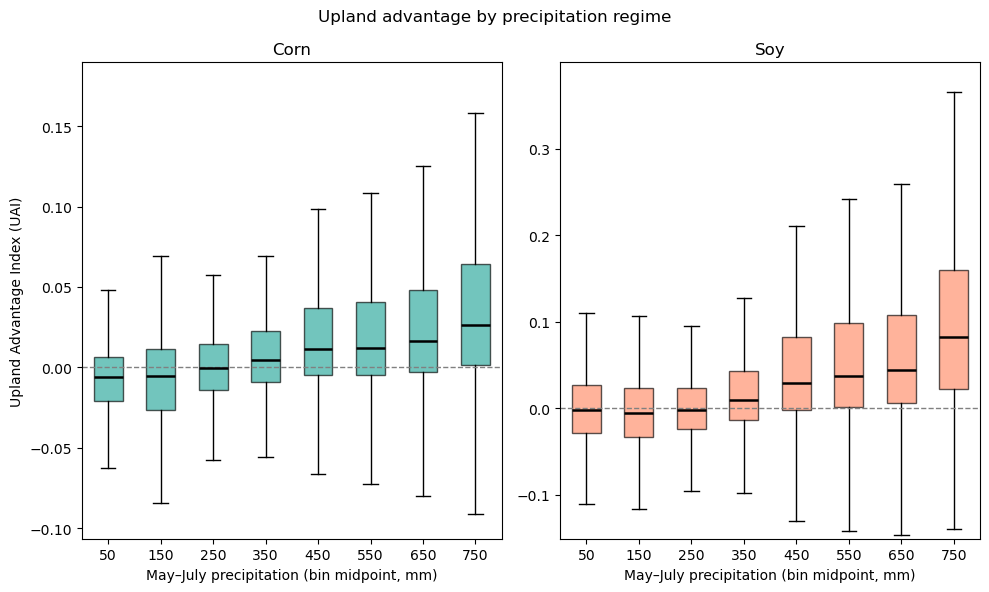

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------
# SETTINGS
# ---------------------------------------------
PRECIP_COL = "ppt_MJJ"

# Pretty binning
BIN_STEP = 100     # mm
MIN_PER_BIN = 200

# Outlier trimming (Tukey fence)
IQR_MULT = 1.5

# Y-axis zoom
Y_Q_LO, Y_Q_HI = 0.001, 1
Y_PAD_FRAC = 0.05

# Box aesthetics
BOX_WIDTH = 0.55
BOX_ALPHA = 0.65
EDGE_LW = 1.0
MEDIAN_LW = 1.8

# Colors
COLORS = {
    "corn": "#26A69A",   # teal
    "soy":  "#FF8A65",   # soft coral
}

CROPS = ["corn", "soy"]

# ---------------------------------------------
# HELPER FUNCTION
# ---------------------------------------------
def prep_binned_data(df, crop):
    dfm = df.loc[
        (df["crop"] == crop) &
        (~df[PRECIP_COL].isna()) &
        (~df["UAI"].isna())
    ].copy()

    if dfm.empty:
        raise ValueError(f"No data for crop={crop}")

    xmin = float(dfm[PRECIP_COL].min())
    xmax = float(dfm[PRECIP_COL].max())

    left = np.floor(xmin / BIN_STEP) * BIN_STEP
    right = np.ceil(xmax / BIN_STEP) * BIN_STEP
    edges = np.arange(left, right + BIN_STEP, BIN_STEP)

    dfm["ppt_bin"] = pd.cut(dfm[PRECIP_COL], bins=edges, include_lowest=True, right=False)

    labels = [f"{int(edges[i])}–{int(edges[i+1])}" for i in range(len(edges) - 1)]
    dfm["ppt_bin_label"] = pd.Categorical(
        dfm["ppt_bin"].cat.rename_categories(labels),
        categories=labels,
        ordered=True
    )

    # Outlier trimming
    g = dfm.groupby("ppt_bin_label", observed=True)["UAI"]
    q1 = g.transform(lambda s: s.quantile(0.25))
    q3 = g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1

    lo = q1 - IQR_MULT * iqr
    hi = q3 + IQR_MULT * iqr

    df_clean = dfm[(dfm["UAI"] >= lo) & (dfm["UAI"] <= hi)].copy()

    counts = df_clean["ppt_bin_label"].value_counts().reindex(labels)
    keep_bins = counts[counts >= MIN_PER_BIN].index.tolist()
    df_clean = df_clean[df_clean["ppt_bin_label"].isin(keep_bins)].copy()

    data_by_bin = [
        df_clean.loc[df_clean["ppt_bin_label"] == b, "UAI"].values
        for b in keep_bins
    ]

    bin_midpoints = [
        int((int(b.split("–")[0]) + int(b.split("–")[1])) / 2)
        for b in keep_bins
    ]

    ylo, yhi = df_clean["UAI"].quantile([Y_Q_LO, Y_Q_HI]).values
    pad = Y_PAD_FRAC * (yhi - ylo)

    return {
        "data": data_by_bin,
        "midpoints": bin_midpoints,
        "ylo": ylo - pad,
        "yhi": yhi + pad,
    }

# ---------------------------------------------
# PREP DATA
# ---------------------------------------------
prep = {crop: prep_binned_data(merged, crop) for crop in CROPS}

# ---------------------------------------------
# PLOT (NOTE: sharey=False)
# ---------------------------------------------
fig, axes = plt.subplots(
    ncols=2,
    figsize=(10, 6),
    sharey=False  # <-- CHANGE 1
)

for ax, crop in zip(axes, CROPS):
    p = prep[crop]

    bp = ax.boxplot(
        p["data"],
        patch_artist=True,
        showfliers=False,
        widths=BOX_WIDTH,
        medianprops=dict(color="black", linewidth=MEDIAN_LW),
        whiskerprops=dict(color="black", linewidth=EDGE_LW),
        capprops=dict(color="black", linewidth=EDGE_LW),
    )

    for box in bp["boxes"]:
        box.set_facecolor(COLORS[crop])
        box.set_alpha(BOX_ALPHA)
        box.set_edgecolor("black")
        box.set_linewidth(EDGE_LW)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    # <-- CHANGE 2: per-panel y-limits
    ax.set_ylim(p["ylo"], p["yhi"])

    ax.set_xticks(range(1, len(p["midpoints"]) + 1))
    ax.set_xticklabels(p["midpoints"])
    ax.set_xlabel("May–July precipitation (bin midpoint, mm)")
    ax.set_title(crop.capitalize())

    ax.grid(False)

axes[0].set_ylabel("Upland Advantage Index (UAI)")

plt.suptitle("Upland advantage by precipitation regime", y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
# combined script for 4-panel figure

In [ ]:
## new version

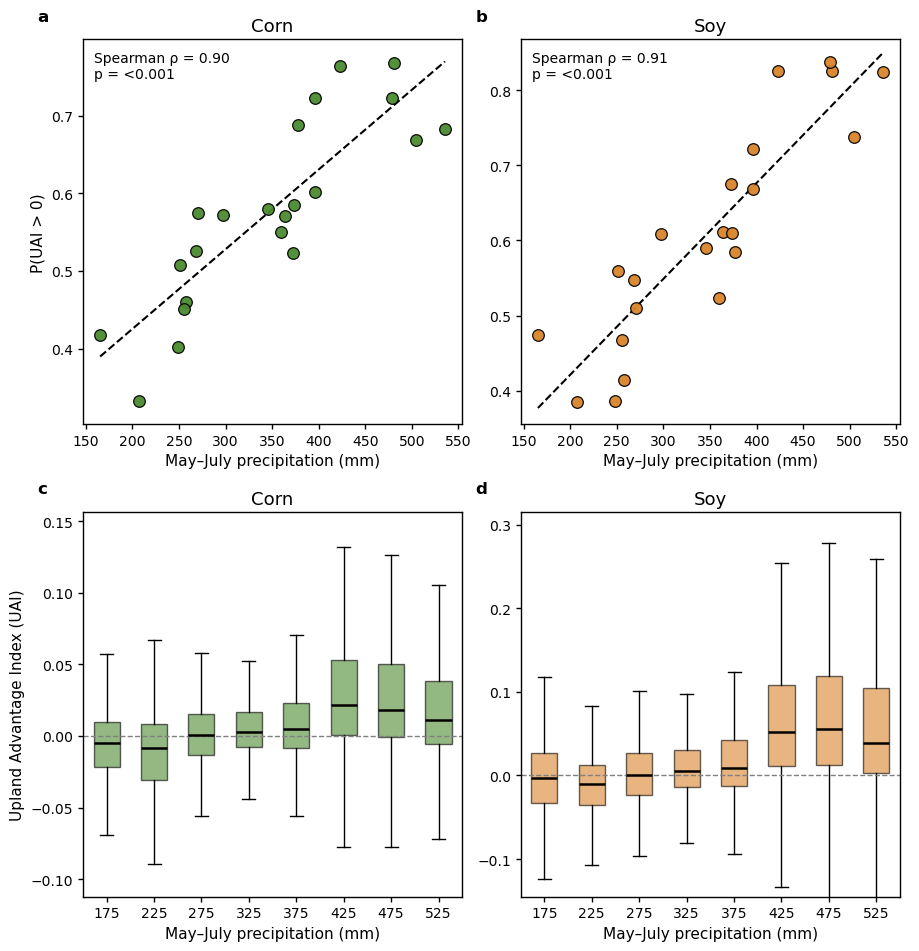

[SAVED] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/PRISM_precip_monthly/metrics/Figure_precip_uai_4panel_ppt_MJJ.png
[SAVED] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/PRISM_precip_monthly/metrics/Figure_precip_uai_4panel_ppt_MJJ.jpg
[SAVED] correlation table: /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/PRISM_precip_monthly/metrics/precip_uai_correlations_wetland_centroids.csv


In [4]:
#!/usr/bin/env python3
"""
4-panel precipitation–UAI figure (single combined figure):
  (a) Corn: P(UAI>0) vs ppt_MJJ (scatter, by year)
  (b) Soy:  P(UAI>0) vs ppt_MJJ (scatter, by year)
  (c) Corn: UAI distribution across ppt_MJJ bins (boxplots)
  (d) Soy:  UAI distribution across ppt_MJJ bins (boxplots)

Precipitation is sampled at wetland centroids and summarized across wetlands per year.
Boxplots bin UAI observations by the year-level ppt_MJJ for that year.

Inputs:
  - wetland_precip_metrics_centroid_2003_2024.csv
    (wetland_id, year, metric, mean, median, p10, p90, ...)
  - UAI_prepped_AUGUST.csv
    (year, crop, UAI, ...)

Outputs (single combined figure):
  - Figure_precip_uai_4panel_ppt_MJJ.png
  - Figure_precip_uai_4panel_ppt_MJJ.jpg
  - precip_uai_correlations_wetland_centroids.csv (optional table)

Author: Kimberly Van Meter
"""

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import os


# -------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------
PRISM_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics"

UAI_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"

PRECIP_WETLAND_CSV = PRISM_ROOT / "wetland_precip_metrics_centroid_2003_2024.csv"
UAI_CSV            = UAI_ROOT / "UAI_prepped_AUGUST.csv"

OUT_FIG_PNG = PRISM_ROOT / "Figure_precip_uai_4panel_ppt_MJJ.png"
OUT_FIG_JPG = PRISM_ROOT / "Figure_precip_uai_4panel_ppt_MJJ.jpg"
OUT_CSV     = PRISM_ROOT / "precip_uai_correlations_wetland_centroids.csv"


# -------------------------------------------------------------------
# SETTINGS
# -------------------------------------------------------------------
CROPS = ["corn", "soy"]

# Use ONE precip metric for the 4-panel figure
PRECIP_COL = "ppt_MJJ"
PRECIP_LABEL = "May–July precipitation (mm)"  # label for ppt_MJJ

# centroid precip: pick wetland-level column (centroid == same; keep mean)
WETLAND_VALUE_COL = "mean"

# summarize across wetlands to get a single year-level precip covariate
YEAR_SUMMARY = "mean"   # mean|median|p10|p90

MIN_N_PER_YEAR = 10

# ---- Figure layout (portrait) ----
FIGSIZE = (9.2, 9.6)  # (width, height) portrait
DPI = 300
SHOW_IN_NOTEBOOK = True

# Scatter aesthetics
SCATTER_S   = 70
SCATTER_A   = 0.95
LINE_LW     = 1.5

# Tight y-lims for scatterplots (reduce whitespace)
SCATTER_Y_PAD = 0.03  # probability units

# Stats display choice:
# - For bounded, potentially non-linear relationships, Spearman rho is usually the better “headline”.
# - You *can* also report linear R², but it’s model-dependent.
SHOW_R2_ON_PLOT = False

# Boxplot aesthetics
IQR_MULT    = 1.5
BOX_WIDTH   = 0.55
BOX_ALPHA   = 0.60
EDGE_LW     = 1.0
MEDIAN_LW   = 1.8
REF_LW      = 1.0
Y_Q_LO, Y_Q_HI = 0.001, 1
Y_PAD_FRAC  = 0.05

# ---- BINNING (more bins) ----
BIN_STEP    = 50      # smaller = more bins
MIN_PER_BIN = 150     # minimum obs per bin (after trimming)

# ---- COLORS ----
CORN_COLOR = "#4C8A2F"
SOY_COLOR  = "#D9842B"
CROP_COLOR = {"corn": CORN_COLOR, "soy": SOY_COLOR}


# -------------------------------------------------------------------
# HELPERS
# -------------------------------------------------------------------
def style_axes(ax):
    """Paper-style axes: full border, no grid."""
    ax.grid(False)
    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_linewidth(1.0)
    ax.tick_params(width=1.0)

def fmt_p(p, thresh=0.001):
    """Format p-values with <0.001 threshold."""
    if p is None or np.isnan(p):
        return "NA"
    return "<0.001" if p < thresh else f"{p:.3f}"

def summarize_year_precip(precip_wet: pd.DataFrame) -> pd.DataFrame:
    """Return year × metric precip table (wide)."""
    if WETLAND_VALUE_COL not in precip_wet.columns:
        raise ValueError(
            f"WETLAND_VALUE_COL='{WETLAND_VALUE_COL}' not found in precip file columns.\n"
            f"Available columns: {list(precip_wet.columns)}"
        )

    pw = precip_wet[["wetland_id", "year", "metric", WETLAND_VALUE_COL]].rename(
        columns={WETLAND_VALUE_COL: "wetland_value"}
    )

    if YEAR_SUMMARY == "mean":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].mean()
    elif YEAR_SUMMARY == "median":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].median()
    elif YEAR_SUMMARY == "p10":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].quantile(0.10)
    elif YEAR_SUMMARY == "p90":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].quantile(0.90)
    else:
        raise ValueError("YEAR_SUMMARY must be one of: mean, median, p10, p90")

    precip_year = precip_year.rename(columns={"wetland_value": "value"})
    precip_wide = precip_year.pivot(index="year", columns="metric", values="value").reset_index()
    return precip_wide

def compute_prob_uai_gt0(df_uai: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for crop in CROPS:
        dfc = df_uai[df_uai["crop"] == crop]
        for yr in sorted(dfc["year"].unique()):
            sub = dfc.loc[dfc["year"] == yr, "UAI"].dropna()
            if sub.size < MIN_N_PER_YEAR:
                continue
            rows.append({
                "year": int(yr),
                "crop": crop,
                "prob_upland_adv": float(np.mean(sub > 0)),
                "n": int(sub.size),
            })
    return pd.DataFrame(rows)

def linear_r2(x, y):
    """Simple linear R² for y ~ x (used optionally)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2:
        return np.nan
    b = np.polyfit(x, y, 1)
    yhat = np.polyval(b, x)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return np.nan if ss_tot == 0 else (1 - ss_res / ss_tot)

def set_scatter_ylim(ax, y):
    """Tight y-lims for probability scatterplots."""
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        ax.set_ylim(0, 1)
        return
    lo = max(0.0, float(np.min(y) - SCATTER_Y_PAD))
    hi = min(1.0, float(np.max(y) + SCATTER_Y_PAD))
    # avoid degenerate range
    if hi - lo < 0.08:
        mid = 0.5 * (hi + lo)
        lo = max(0.0, mid - 0.04)
        hi = min(1.0, mid + 0.04)
    ax.set_ylim(lo, hi)

def prep_binned_data(df_obs: pd.DataFrame, crop: str):
    """Prepare UAI arrays binned by year-level precip for boxplots."""
    dfm = df_obs.loc[
        (df_obs["crop"] == crop) &
        (~df_obs[PRECIP_COL].isna()) &
        (~df_obs["UAI"].isna())
    ].copy()

    if dfm.empty:
        raise ValueError(f"No data for crop={crop} after filtering.")

    xmin = float(dfm[PRECIP_COL].min())
    xmax = float(dfm[PRECIP_COL].max())

    left = np.floor(xmin / BIN_STEP) * BIN_STEP
    right = np.ceil(xmax / BIN_STEP) * BIN_STEP
    edges = np.arange(left, right + BIN_STEP, BIN_STEP)

    dfm["ppt_bin"] = pd.cut(dfm[PRECIP_COL], bins=edges, include_lowest=True, right=False)
    labels = [f"{int(edges[i])}–{int(edges[i+1])}" for i in range(len(edges) - 1)]
    dfm["ppt_bin_label"] = pd.Categorical(
        dfm["ppt_bin"].cat.rename_categories(labels),
        categories=labels,
        ordered=True
    )

    # Outlier trimming within each bin (Tukey fence)
    g = dfm.groupby("ppt_bin_label", observed=True)["UAI"]
    q1 = g.transform(lambda s: s.quantile(0.25))
    q3 = g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    lo = q1 - IQR_MULT * iqr
    hi = q3 + IQR_MULT * iqr
    df_clean = dfm[(dfm["UAI"] >= lo) & (dfm["UAI"] <= hi)].copy()

    counts = df_clean["ppt_bin_label"].value_counts().reindex(labels)
    keep_bins = counts[counts >= MIN_PER_BIN].index.tolist()
    df_clean = df_clean[df_clean["ppt_bin_label"].isin(keep_bins)].copy()

    data_by_bin = [
        df_clean.loc[df_clean["ppt_bin_label"] == b, "UAI"].values
        for b in keep_bins
    ]
    bin_midpoints = [
        int((int(b.split("–")[0]) + int(b.split("–")[1])) / 2)
        for b in keep_bins
    ]

    ylo, yhi = df_clean["UAI"].quantile([Y_Q_LO, Y_Q_HI]).values
    pad = Y_PAD_FRAC * (yhi - ylo)

    return {
        "data": data_by_bin,
        "midpoints": bin_midpoints,
        "ylo": float(ylo - pad),
        "yhi": float(yhi + pad),
    }


# -------------------------------------------------------------------
# LOAD + BUILD MERGED TABLES
# -------------------------------------------------------------------
precip_wet = pd.read_csv(PRECIP_WETLAND_CSV)
df_uai = pd.read_csv(UAI_CSV)

precip_wet["year"] = precip_wet["year"].astype(int)
precip_wet["metric"] = precip_wet["metric"].astype(str)

df_uai = df_uai[["year", "crop", "UAI"]].dropna()
df_uai["year"] = df_uai["year"].astype(int)
df_uai["crop"] = df_uai["crop"].astype(str).str.lower().str.strip()

precip_wide = summarize_year_precip(precip_wet)

if PRECIP_COL not in precip_wide.columns:
    raise ValueError(f"{PRECIP_COL} not found in precip_wide columns: {list(precip_wide.columns)}")

uai_prob = compute_prob_uai_gt0(df_uai)

# merged for scatter (one row per crop×year)
merged_scatter = (
    uai_prob.merge(precip_wide[["year", PRECIP_COL]], on="year", how="left")
    .dropna(subset=[PRECIP_COL])
)

# merged for boxplots (UAI observations joined to year-level precip)
merged_obs = (
    df_uai.merge(precip_wide[["year", PRECIP_COL]], on="year", how="left")
    .dropna(subset=[PRECIP_COL])
)

# Optional: correlation table output (ppt_MJJ only)
rows_corr = []
for crop in CROPS:
    dfc = merged_scatter[merged_scatter["crop"] == crop].dropna(subset=[PRECIP_COL, "prob_upland_adv"])
    if len(dfc) >= 3:
        x = dfc[PRECIP_COL].values
        y = dfc["prob_upland_adv"].values
        r_pear, p_pear = stats.pearsonr(x, y)
        rho, p_spear = stats.spearmanr(x, y)
        r2 = linear_r2(x, y)
        rows_corr.append({
            "crop": crop,
            "metric": PRECIP_COL,
            "wetland_value_col": WETLAND_VALUE_COL,
            "year_summary": YEAR_SUMMARY,
            "pearson_r": float(r_pear),
            "pearson_p": float(p_pear),
            "spearman_rho": float(rho),
            "spearman_p": float(p_spear),
            "linear_r2": float(r2) if np.isfinite(r2) else np.nan,
            "n_years": int(len(dfc)),
        })
df_corr = pd.DataFrame(rows_corr)
df_corr.to_csv(OUT_CSV, index=False)


# -------------------------------------------------------------------
# PLOT: 4-panel figure
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)

# -------------------------
# (a) Corn scatter
# -------------------------
ax = axes[0, 0]
crop = "corn"
dfc = merged_scatter[merged_scatter["crop"] == crop].copy()
x = dfc[PRECIP_COL].values
y = dfc["prob_upland_adv"].values

ax.scatter(
    x, y,
    s=SCATTER_S,
    alpha=SCATTER_A,
    facecolor=CROP_COLOR[crop],
    edgecolor="black",
    linewidth=0.9,
    zorder=3
)

# fit line
if len(x) >= 2:
    b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, np.polyval(b, xx), linestyle="--", linewidth=LINE_LW, color="black", zorder=2)

# annotate correlation: Spearman (primary)
if len(x) >= 3:
    rho, pval = stats.spearmanr(x, y)
    msg = f"Spearman ρ = {rho:.2f}\np = {fmt_p(pval)}"
    if SHOW_R2_ON_PLOT:
        r2 = linear_r2(x, y)
        if np.isfinite(r2):
            msg += f"\nLinear R² = {r2:.2f}"
    ax.text(
        0.03, 0.97, msg,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

ax.set_title("Corn", fontsize=13)
ax.set_xlabel(PRECIP_LABEL, fontsize=11)
ax.set_ylabel("P(UAI > 0)", fontsize=11)
set_scatter_ylim(ax, y)
style_axes(ax)
ax.text(-0.12, 1.04, "a", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# -------------------------
# (b) Soy scatter
# -------------------------
ax = axes[0, 1]
crop = "soy"
dfc = merged_scatter[merged_scatter["crop"] == crop].copy()
x = dfc[PRECIP_COL].values
y = dfc["prob_upland_adv"].values

ax.scatter(
    x, y,
    s=SCATTER_S,
    alpha=SCATTER_A,
    facecolor=CROP_COLOR[crop],
    edgecolor="black",
    linewidth=0.9,
    zorder=3
)

if len(x) >= 2:
    b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, np.polyval(b, xx), linestyle="--", linewidth=LINE_LW, color="black", zorder=2)

if len(x) >= 3:
    rho, pval = stats.spearmanr(x, y)
    msg = f"Spearman ρ = {rho:.2f}\np = {fmt_p(pval)}"
    if SHOW_R2_ON_PLOT:
        r2 = linear_r2(x, y)
        if np.isfinite(r2):
            msg += f"\nLinear R² = {r2:.2f}"
    ax.text(
        0.03, 0.97, msg,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10
    )

ax.set_title("Soy", fontsize=13)
ax.set_xlabel(PRECIP_LABEL, fontsize=11)
ax.set_ylabel("")  # keep right panel clean
set_scatter_ylim(ax, y)
style_axes(ax)
ax.text(-0.12, 1.04, "b", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# -------------------------
# (c) Corn boxplots by precip bins
# -------------------------
ax = axes[1, 0]
crop = "corn"
p = prep_binned_data(merged_obs, crop)

bp = ax.boxplot(
    p["data"],
    patch_artist=True,
    showfliers=False,
    widths=BOX_WIDTH,
    medianprops=dict(color="black", linewidth=MEDIAN_LW),
    whiskerprops=dict(color="black", linewidth=EDGE_LW),
    capprops=dict(color="black", linewidth=EDGE_LW),
)

for box in bp["boxes"]:
    box.set_facecolor(CROP_COLOR[crop])
    box.set_alpha(BOX_ALPHA)
    box.set_edgecolor("black")
    box.set_linewidth(EDGE_LW)

ax.axhline(0, color="0.5", linestyle="--", linewidth=REF_LW)
ax.set_ylim(p["ylo"], p["yhi"])
ax.set_xticks(range(1, len(p["midpoints"]) + 1))
ax.set_xticklabels(p["midpoints"])
ax.set_xlabel("May–July precipitation (mm)", fontsize=11)
ax.set_ylabel("Upland Advantage Index (UAI)", fontsize=11)
ax.set_title("Corn", fontsize=13)
style_axes(ax)
ax.text(-0.12, 1.04, "c", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# -------------------------
# (d) Soy boxplots by precip bins
# -------------------------
ax = axes[1, 1]
crop = "soy"
p = prep_binned_data(merged_obs, crop)

bp = ax.boxplot(
    p["data"],
    patch_artist=True,
    showfliers=False,
    widths=BOX_WIDTH,
    medianprops=dict(color="black", linewidth=MEDIAN_LW),
    whiskerprops=dict(color="black", linewidth=EDGE_LW),
    capprops=dict(color="black", linewidth=EDGE_LW),
)

for box in bp["boxes"]:
    box.set_facecolor(CROP_COLOR[crop])
    box.set_alpha(BOX_ALPHA)
    box.set_edgecolor("black")
    box.set_linewidth(EDGE_LW)

ax.axhline(0, color="0.5", linestyle="--", linewidth=REF_LW)
ax.set_ylim(p["ylo"], p["yhi"])
ax.set_xticks(range(1, len(p["midpoints"]) + 1))
ax.set_xticklabels(p["midpoints"])
ax.set_xlabel("May–July precipitation (mm)", fontsize=11)
ax.set_ylabel("")
ax.set_title("Soy", fontsize=13)
style_axes(ax)
ax.text(-0.12, 1.04, "d", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# overall layout + save
plt.tight_layout()
fig.savefig(OUT_FIG_PNG, dpi=DPI, bbox_inches="tight")
fig.savefig(OUT_FIG_JPG, dpi=DPI, bbox_inches="tight")

if SHOW_IN_NOTEBOOK:
    plt.show()

plt.close(fig)

print(f"[SAVED] {OUT_FIG_PNG}")
print(f"[SAVED] {OUT_FIG_JPG}")
print(f"[SAVED] correlation table: {OUT_CSV}")


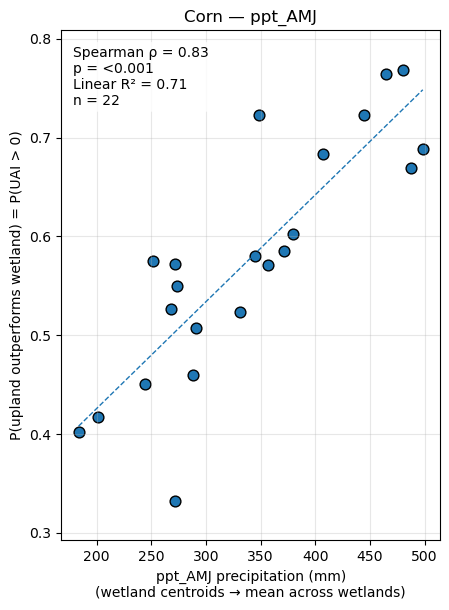

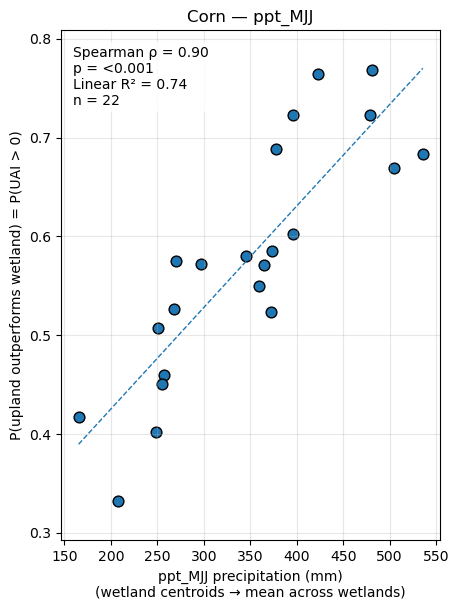

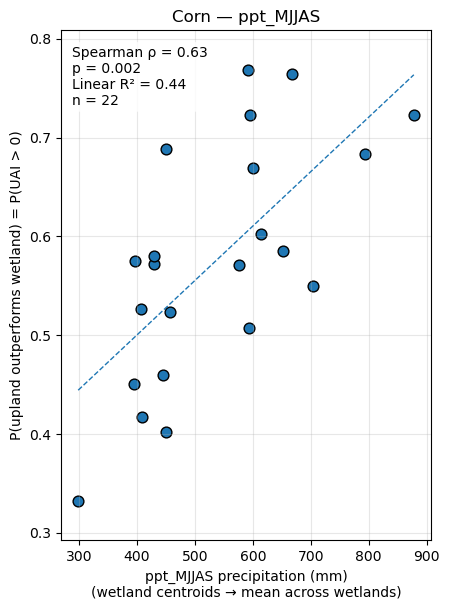

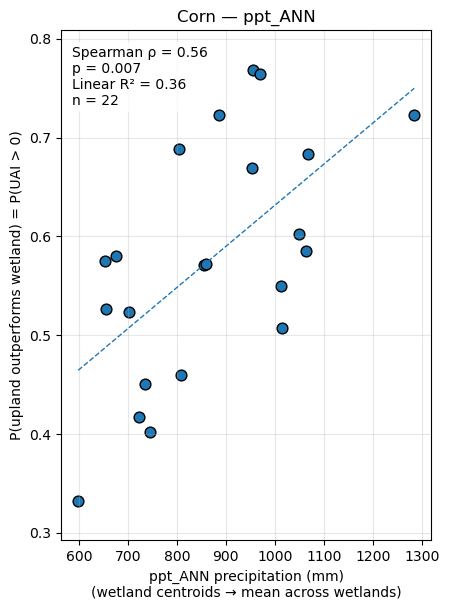

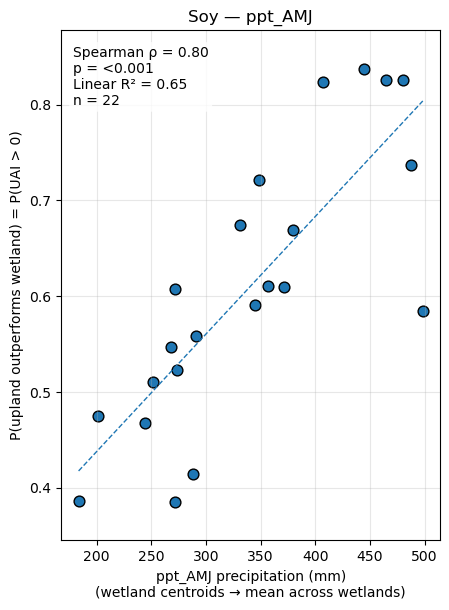

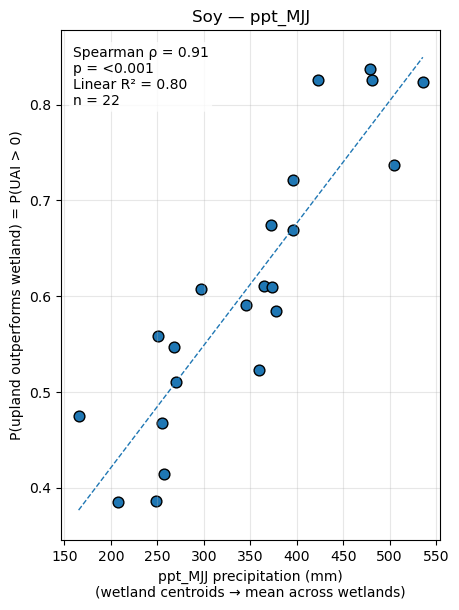

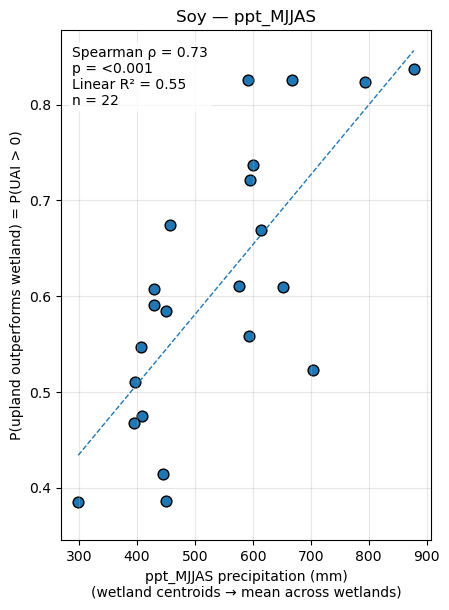

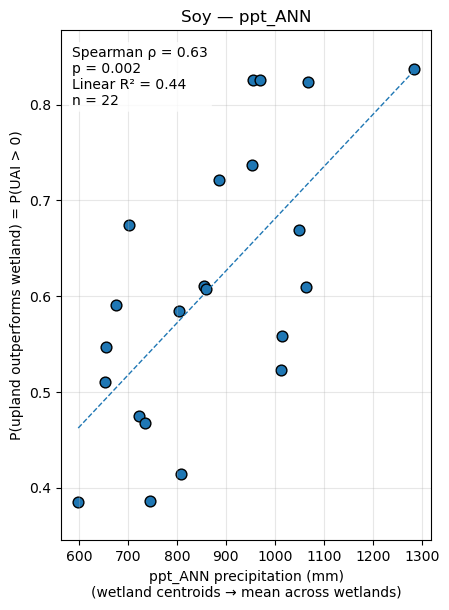


=== Merged (first 20 rows) ===
    year  crop  prob_upland_adv      n     ppt_AMJ      ppt_ANN     ppt_MJJ  \
0   2003  corn         0.523335  54061  330.882220   703.011812  372.603185   
1   2004  corn         0.722932  55037  348.558099   885.482570  396.262745   
2   2005  corn         0.571454  50529  356.976585   854.880704  364.209287   
3   2006  corn         0.417000  65837  200.723389   723.009806  165.329860   
4   2007  corn         0.507183  77966  290.829904  1014.764859  251.250100   
5   2008  corn         0.768505  71535  480.303192   956.238373  481.144466   
6   2009  corn         0.572457  73499  271.214995   858.654128  297.022250   
7   2010  corn         0.683083  73401  406.892176  1066.582482  535.548396   
8   2011  corn         0.580202  75622  344.756954   675.656352  345.549742   
9   2012  corn         0.332398  72338  271.467638   598.724385  207.223535   
10  2013  corn         0.688135  70864  498.336261   805.288762  377.379383   
11  2014  corn      

In [2]:
#!/usr/bin/env python3
"""
4-panel precipitation–UAI figure:
  (a) Corn: P(UAI>0) vs ppt_MJJ (scatter, by year)
  (b) Soy:  P(UAI>0) vs ppt_MJJ (scatter, by year)
  (c) Corn: UAI distribution across ppt_MJJ bins (boxplots)
  (d) Soy:  UAI distribution across ppt_MJJ bins (boxplots)

Precipitation is sampled at wetland centroids and summarized across wetlands per year.
Boxplots bin UAI observations by the year-level ppt_MJJ for that year.

Inputs:
  - wetland_precip_metrics_centroid_2003_2024.csv
    (wetland_id, year, metric, mean, median, p10, p90, ...)
  - UAI_prepped_AUGUST.csv
    (year, crop, UAI, ...)

Outputs (single combined figure):
  - Figure_precip_uai_4panel_ppt_MJJ.png
  - Figure_precip_uai_4panel_ppt_MJJ.jpg
  - precip_uai_correlations_wetland_centroids.csv (optional table)

Author: Kimberly Van Meter
"""

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import os


# -------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------
PRISM_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics"

UAI_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"

PRECIP_WETLAND_CSV = PRISM_ROOT / "wetland_precip_metrics_centroid_2003_2024.csv"
UAI_CSV            = UAI_ROOT / "UAI_prepped_AUGUST.csv"

OUT_FIG_PNG = PRISM_ROOT / "Figure_precip_uai_4panel_ppt_MJJ.png"
OUT_FIG_JPG = PRISM_ROOT / "Figure_precip_uai_4panel_ppt_MJJ.jpg"
OUT_CSV     = PRISM_ROOT / "precip_uai_correlations_wetland_centroids.csv"


# -------------------------------------------------------------------
# SETTINGS
# -------------------------------------------------------------------
CROPS = ["corn", "soy"]

# Use ONE precip metric for the 4-panel figure (matches your examples)
PRECIP_COL = "ppt_MJJ"

# centroid precip: pick wetland-level column (centroid == same; keep mean)
WETLAND_VALUE_COL = "mean"

# summarize across wetlands to get a single year-level precip covariate
YEAR_SUMMARY = "mean"   # mean|median|p10|p90

MIN_N_PER_YEAR = 10

# Scatter aesthetics
SCATTER_S   = 70
SCATTER_A   = 0.95
LINE_LW     = 1.5
REF_LW      = 1.0

# Boxplot aesthetics
IQR_MULT    = 1.5
BOX_WIDTH   = 0.55
BOX_ALPHA   = 0.60
EDGE_LW     = 1.0
MEDIAN_LW   = 1.8
Y_Q_LO, Y_Q_HI = 0.001, 1
Y_PAD_FRAC  = 0.05

# ---- BINNING (more bins) ----
BIN_STEP    = 50      # was 100; smaller = more bins
MIN_PER_BIN = 150     # was 200; relax a bit so bins survive

# ---- COLORS (brighter) ----
CORN_COLOR = "#4C8A2F"  # brighter green
SOY_COLOR  = "#D9842B"  # brighter orange
CROP_COLOR = {"corn": CORN_COLOR, "soy": SOY_COLOR}


# -------------------------------------------------------------------
# HELPERS
# -------------------------------------------------------------------
def style_axes(ax):
    """Paper-style axes: full border, no grid."""
    ax.grid(False)
    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_linewidth(1.0)
    ax.tick_params(width=1.0)

def summarize_year_precip(precip_wet: pd.DataFrame) -> pd.DataFrame:
    """Return year × metric precip table (wide)."""
    pw = precip_wet[["wetland_id", "year", "metric", WETLAND_VALUE_COL]].rename(
        columns={WETLAND_VALUE_COL: "wetland_value"}
    )

    if YEAR_SUMMARY == "mean":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].mean()
    elif YEAR_SUMMARY == "median":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].median()
    elif YEAR_SUMMARY == "p10":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].quantile(0.10)
    elif YEAR_SUMMARY == "p90":
        precip_year = pw.groupby(["year", "metric"], as_index=False)["wetland_value"].quantile(0.90)
    else:
        raise ValueError("YEAR_SUMMARY must be one of: mean, median, p10, p90")

    precip_year = precip_year.rename(columns={"wetland_value": "value"})
    precip_wide = precip_year.pivot(index="year", columns="metric", values="value").reset_index()
    return precip_wide

def compute_prob_uai_gt0(df_uai: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for crop in CROPS:
        dfc = df_uai[df_uai["crop"] == crop]
        for yr in sorted(dfc["year"].unique()):
            sub = dfc.loc[dfc["year"] == yr, "UAI"].dropna()
            if sub.size < MIN_N_PER_YEAR:
                continue
            rows.append({
                "year": int(yr),
                "crop": crop,
                "prob_upland_adv": float(np.mean(sub > 0)),
                "n": int(sub.size),
            })
    return pd.DataFrame(rows)

def prep_binned_data(df_obs: pd.DataFrame, crop: str):
    """Prepare UAI arrays binned by year-level precip for boxplots."""
    dfm = df_obs.loc[
        (df_obs["crop"] == crop) &
        (~df_obs[PRECIP_COL].isna()) &
        (~df_obs["UAI"].isna())
    ].copy()

    if dfm.empty:
        raise ValueError(f"No data for crop={crop} after filtering.")

    xmin = float(dfm[PRECIP_COL].min())
    xmax = float(dfm[PRECIP_COL].max())

    left = np.floor(xmin / BIN_STEP) * BIN_STEP
    right = np.ceil(xmax / BIN_STEP) * BIN_STEP
    edges = np.arange(left, right + BIN_STEP, BIN_STEP)

    dfm["ppt_bin"] = pd.cut(dfm[PRECIP_COL], bins=edges, include_lowest=True, right=False)
    labels = [f"{int(edges[i])}–{int(edges[i+1])}" for i in range(len(edges) - 1)]
    dfm["ppt_bin_label"] = pd.Categorical(
        dfm["ppt_bin"].cat.rename_categories(labels),
        categories=labels,
        ordered=True
    )

    # Outlier trimming within each bin (Tukey fence)
    g = dfm.groupby("ppt_bin_label", observed=True)["UAI"]
    q1 = g.transform(lambda s: s.quantile(0.25))
    q3 = g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    lo = q1 - IQR_MULT * iqr
    hi = q3 + IQR_MULT * iqr
    df_clean = dfm[(dfm["UAI"] >= lo) & (dfm["UAI"] <= hi)].copy()

    counts = df_clean["ppt_bin_label"].value_counts().reindex(labels)
    keep_bins = counts[counts >= MIN_PER_BIN].index.tolist()
    df_clean = df_clean[df_clean["ppt_bin_label"].isin(keep_bins)].copy()

    data_by_bin = [
        df_clean.loc[df_clean["ppt_bin_label"] == b, "UAI"].values
        for b in keep_bins
    ]
    bin_midpoints = [
        int((int(b.split("–")[0]) + int(b.split("–")[1])) / 2)
        for b in keep_bins
    ]

    ylo, yhi = df_clean["UAI"].quantile([Y_Q_LO, Y_Q_HI]).values
    pad = Y_PAD_FRAC * (yhi - ylo)

    return {
        "data": data_by_bin,
        "midpoints": bin_midpoints,
        "ylo": float(ylo - pad),
        "yhi": float(yhi + pad),
    }


# -------------------------------------------------------------------
# LOAD + BUILD MERGED TABLES
# -------------------------------------------------------------------
precip_wet = pd.read_csv(PRECIP_WETLAND_CSV)
df_uai = pd.read_csv(UAI_CSV)

precip_wet["year"] = precip_wet["year"].astype(int)
precip_wet["metric"] = precip_wet["metric"].astype(str)

# keep only what we need from UAI
df_uai = df_uai[["year", "crop", "UAI"]].dropna()
df_uai["year"] = df_uai["year"].astype(int)
df_uai["crop"] = df_uai["crop"].astype(str).str.lower().str.strip()

# year-level precip (wide)
precip_wide = summarize_year_precip(precip_wet)

if PRECIP_COL not in precip_wide.columns:
    raise ValueError(f"{PRECIP_COL} not found in precip_wide columns: {list(precip_wide.columns)}")

# year-level P(UAI>0)
uai_prob = compute_prob_uai_gt0(df_uai)

# merged for scatter (one row per crop×year)
merged_scatter = uai_prob.merge(precip_wide[["year", PRECIP_COL]], on="year", how="left").dropna(subset=[PRECIP_COL])

# merged for boxplots (UAI observations joined to year-level precip)
merged_obs = df_uai.merge(precip_wide[["year", PRECIP_COL]], on="year", how="left").dropna(subset=[PRECIP_COL])


# Optional: correlation table output (ppt_MJJ only, for reporting)
rows_corr = []
for crop in CROPS:
    dfc = merged_scatter[merged_scatter["crop"] == crop].dropna(subset=[PRECIP_COL, "prob_upland_adv"])
    if len(dfc) >= 3:
        x = dfc[PRECIP_COL].values
        y = dfc["prob_upland_adv"].values
        r_pear, p_pear = stats.pearsonr(x, y)
        r_spear, p_spear = stats.spearmanr(x, y)
        rows_corr.append({
            "crop": crop,
            "metric": PRECIP_COL,
            "wetland_value_col": WETLAND_VALUE_COL,
            "year_summary": YEAR_SUMMARY,
            "pearson_r": float(r_pear),
            "pearson_p": float(p_pear),
            "spearman_r": float(r_spear),
            "spearman_p": float(p_spear),
            "n_years": int(len(dfc)),
        })
df_corr = pd.DataFrame(rows_corr)
df_corr.to_csv(OUT_CSV, index=False)


# -------------------------------------------------------------------
# PLOT: 4-panel figure
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# -------------------------
# (a) Corn scatter
# -------------------------
ax = axes[0, 0]
crop = "corn"
dfc = merged_scatter[merged_scatter["crop"] == crop].copy()
x = dfc[PRECIP_COL].values
y = dfc["prob_upland_adv"].values

ax.scatter(x, y, s=SCATTER_S, alpha=SCATTER_A,
           facecolor=CROP_COLOR[crop], edgecolor="black", linewidth=0.9, zorder=3)

# fit line
if len(x) >= 2:
    b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, np.polyval(b, xx), linestyle="--", linewidth=LINE_LW, color="black", zorder=2)

# annotate correlation (Spearman is robust + intuitive)
if len(x) >= 3:
    rho, pval = stats.spearmanr(x, y)
    ax.text(0.03, 0.97, f"Spearman ρ={rho:.2f}\np={pval:.3g}",
            transform=ax.transAxes, ha="left", va="top", fontsize=10)

ax.set_title("Corn", fontsize=13)
ax.set_xlabel(f"Spring Precipitation (mm)", fontsize=11)
ax.set_ylabel("P(UAI > 0)", fontsize=11)
ax.set_ylim(0, 1)
style_axes(ax)
ax.text(-0.12, 1.04, "a", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# -------------------------
# (b) Soy scatter
# -------------------------
ax = axes[0, 1]
crop = "soy"
dfc = merged_scatter[merged_scatter["crop"] == crop].copy()
x = dfc[PRECIP_COL].values
y = dfc["prob_upland_adv"].values

ax.scatter(x, y, s=SCATTER_S, alpha=SCATTER_A,
           facecolor=CROP_COLOR[crop], edgecolor="black", linewidth=0.9, zorder=3)

if len(x) >= 2:
    b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, np.polyval(b, xx), linestyle="--", linewidth=LINE_LW, color="black", zorder=2)

if len(x) >= 3:
    rho, pval = stats.spearmanr(x, y)
    ax.text(0.03, 0.97, f"Spearman ρ={rho:.2f}\np={pval:.3g}",
            transform=ax.transAxes, ha="left", va="top", fontsize=10)

ax.set_title("Soy", fontsize=13)
ax.set_xlabel(f"Spring Precipitation (mm)", fontsize=11)
ax.set_ylabel("")  # keep right panel clean
ax.set_ylim(0, 1)
style_axes(ax)
ax.text(-0.12, 1.04, "b", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# -------------------------
# (c) Corn boxplots by precip bins
# -------------------------
ax = axes[1, 0]
crop = "corn"
p = prep_binned_data(merged_obs, crop)

bp = ax.boxplot(
    p["data"],
    patch_artist=True,
    showfliers=False,
    widths=BOX_WIDTH,
    medianprops=dict(color="black", linewidth=MEDIAN_LW),
    whiskerprops=dict(color="black", linewidth=EDGE_LW),
    capprops=dict(color="black", linewidth=EDGE_LW),
)

for box in bp["boxes"]:
    box.set_facecolor(CROP_COLOR[crop])
    box.set_alpha(BOX_ALPHA)
    box.set_edgecolor("black")
    box.set_linewidth(EDGE_LW)

ax.axhline(0, color="0.5", linestyle="--", linewidth=REF_LW)
ax.set_ylim(p["ylo"], p["yhi"])
ax.set_xticks(range(1, len(p["midpoints"]) + 1))
ax.set_xticklabels(p["midpoints"])
ax.set_xlabel("May–July precipitation (bin midpoint, mm)", fontsize=11)
ax.set_ylabel("Upland Advantage Index (UAI)", fontsize=11)
ax.set_title("Corn", fontsize=13)
style_axes(ax)
ax.text(-0.12, 1.04, "c", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# -------------------------
# (d) Soy boxplots by precip bins
# -------------------------
ax = axes[1, 1]
crop = "soy"
p = prep_binned_data(merged_obs, crop)

bp = ax.boxplot(
    p["data"],
    patch_artist=True,
    showfliers=False,
    widths=BOX_WIDTH,
    medianprops=dict(color="black", linewidth=MEDIAN_LW),
    whiskerprops=dict(color="black", linewidth=EDGE_LW),
    capprops=dict(color="black", linewidth=EDGE_LW),
)

for box in bp["boxes"]:
    box.set_facecolor(CROP_COLOR[crop])
    box.set_alpha(BOX_ALPHA)
    box.set_edgecolor("black")
    box.set_linewidth(EDGE_LW)

ax.axhline(0, color="0.5", linestyle="--", linewidth=REF_LW)
ax.set_ylim(p["ylo"], p["yhi"])
ax.set_xticks(range(1, len(p["midpoints"]) + 1))
ax.set_xticklabels(p["midpoints"])
ax.set_xlabel("May–July precipitation (bin midpoint, mm)", fontsize=11)
ax.set_ylabel("")
ax.set_title("Soy", fontsize=13)
style_axes(ax)
ax.text(-0.12, 1.04, "d", transform=ax.transAxes, fontsize=12, fontweight="bold", va="bottom", ha="left")

# overall layout
plt.tight_layout()
fig.savefig(OUT_FIG_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUT_FIG_JPG, dpi=300, bbox_inches="tight")

plt.show(fig)
plt.close(fig)

print(f"[SAVED] {OUT_FIG_PNG}")
print(f"[SAVED] {OUT_FIG_JPG}")
print(f"[SAVED] correlation table: {OUT_CSV}")


In [ ]:
# precipitation quantiles

In [39]:
# ---------------------------------------------
# May–July precipitation quantiles (all wetlands)
# ---------------------------------------------
quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

ppt_quantiles_all = (
    merged["ppt_MJJ"]
    .dropna()
    .quantile(quantiles)
    .rename("ppt_MJJ_mm")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

ppt_quantiles_all["ppt_MJJ_mm"] = ppt_quantiles_all["ppt_MJJ_mm"].round(1)

ppt_quantiles_all


,quantile,ppt_MJJ_mm
0,0.01,126.7
1,0.05,174.9
2,0.10,204.5
3,0.25,257.4
4,0.50,328.3
5,0.75,414.7
6,0.90,513.6
7,0.95,565.7
8,0.99,647.8


In [15]:
def plot_uai_by_precip_bins(dfin, crop, month, box_color, title_suffix):
    # -------------------------------------------------
    # Defensive cleaning
    # -------------------------------------------------
    dfin = dfin.dropna(subset=["UAI_EVI2", PRECIP_COL]).copy()

    if dfin.empty:
        print(f"[SKIP] {crop} month={month}: no data after dropping NaNs")
        return

    print(f"{crop} month={month}: {len(dfin):,} wetland–year points")

    # -------------------------------------------------
    # Build pretty fixed bins (robust to edge cases)
    # -------------------------------------------------
    xmin = float(dfin[PRECIP_COL].min())
    xmax = float(dfin[PRECIP_COL].max())

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin >= xmax:
        print(f"[SKIP] {crop} month={month}: invalid precip range ({xmin}, {xmax})")
        return

    left = np.floor(xmin / BIN_STEP) * BIN_STEP
    right = np.ceil(xmax / BIN_STEP) * BIN_STEP

    # Ensure at least two bin edges
    edges = np.arange(left, right + BIN_STEP, BIN_STEP)
    if len(edges) < 2:
        print(f"[SKIP] {crop} month={month}: insufficient bin edges")
        return

    # Assign bins
    dfin["ppt_bin"] = pd.cut(
        dfin[PRECIP_COL],
        bins=edges,
        include_lowest=True,
        right=False
    )

    labels = [f"{int(edges[i])}–{int(edges[i+1])}" for i in range(len(edges) - 1)]
    dfin["ppt_bin_label"] = pd.Categorical(
        dfin["ppt_bin"].cat.rename_categories(labels),
        categories=labels,
        ordered=True
    )

    # -------------------------------------------------
    # Outlier trimming within bin (Tukey IQR)
    # -------------------------------------------------
    g = dfin.groupby("ppt_bin_label", observed=True)["UAI_EVI2"]
    q1 = g.transform(lambda s: s.quantile(0.25))
    q3 = g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1

    lo = q1 - IQR_MULT * iqr
    hi = q3 + IQR_MULT * iqr

    df_clean = dfin[(dfin["UAI_EVI2"] >= lo) & (dfin["UAI_EVI2"] <= hi)].copy()

    # Drop sparse bins
    counts = df_clean["ppt_bin_label"].value_counts().reindex(labels)
    keep_bins = counts[counts >= MIN_PER_BIN].index.tolist()
    df_clean = df_clean[df_clean["ppt_bin_label"].isin(keep_bins)].copy()

    if len(keep_bins) < 2:
        print(f"[SKIP] {crop} month={month}: too few populated bins")
        return

    print("Points per bin after trimming:")
    print(df_clean["ppt_bin_label"].value_counts().reindex(keep_bins))

    # -------------------------------------------------
    # Prep data for plotting
    # -------------------------------------------------
    data_by_bin = [
        df_clean.loc[df_clean["ppt_bin_label"] == b, "UAI_EVI2"].values
        for b in keep_bins
    ]

    # Y-axis zoom
    ylo, yhi = df_clean["UAI_EVI2"].quantile([Y_Q_LO, Y_Q_HI]).values
    pad = Y_PAD_FRAC * (yhi - ylo)
    ylo -= pad
    yhi += pad

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig_w = max(7.5, 0.85 * len(keep_bins))
    plt.figure(figsize=(fig_w, 4))

    bp = plt.boxplot(
        data_by_bin,
        patch_artist=True,
        showfliers=False,
        widths=BOX_WIDTH,
        medianprops=dict(color="black", linewidth=MEDIAN_LW),
        whiskerprops=dict(color="black", linewidth=EDGE_LW),
        capprops=dict(color="black", linewidth=EDGE_LW),
    )

    for box in bp["boxes"]:
        box.set_facecolor(box_color)
        box.set_alpha(BOX_ALPHA)
        box.set_edgecolor("black")
        box.set_linewidth(EDGE_LW)

    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.ylim(ylo, yhi)

    plt.xticks(range(1, len(keep_bins) + 1), keep_bins)
    plt.xlabel(f"{PRECIP_COL} precipitation bins (mm)")
    plt.ylabel("Upland Advantage Index (EVI2-based)")
    plt.title(f"{crop.capitalize()} — {title_suffix}")

    plt.grid(axis="y", alpha=0.25)
    plt.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.show()


In [13]:
#!/usr/bin/env python3
"""
Correlate Des Moines Lobe precipitation metrics (2003–2024)
with the probability that historical wetlands underperform uplands
in August (P[UAI > 0]) for corn and soy.

Inputs:
    - PRISM_precip_monthly/metrics/DML_precip_metrics_2003_2024.csv
    - UAI_prepped_AUGUST.csv  (from NDVI_wetlands_figures folder)

Outputs:
    - precip_uai_correlations.csv
    - precip_uai_scatterplots/*.png
    - In a notebook, df_corr and merged are available in the namespace
      and printed to the cell output.

Author: Kimberly Van Meter
"""

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import os

# -------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------

PRISM_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics"

UAI_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"

PRECIP_CSV = PRISM_ROOT / "DML_precip_metrics_2003_2024.csv"
UAI_CSV    = UAI_ROOT / "UAI_prepped_AUGUST.csv"

OUT_CSV = PRISM_ROOT / "precip_uai_correlations.csv"
OUT_FIG_DIR = PRISM_ROOT / "precip_uai_scatterplots"
OUT_FIG_DIR.mkdir(exist_ok=True)

CROPS = ["corn", "soy"]
PRECIP_COLS = ["ppt_AMJ", "ppt_MJJ", "ppt_MJJAS", "ppt_ANN"]

# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------

# --- precip metrics (DML-aggregated) ---
precip = pd.read_csv(PRECIP_CSV)

# Keep only mean precip and pivot to wide format:
#   year, ppt_AMJ, ppt_MJJ, ppt_MJJAS, ppt_ANN
precip = precip[["year", "metric", "mean"]]
precip_wide = precip.pivot(index="year", columns="metric", values="mean")
precip_wide.reset_index(inplace=True)

# --- UAI data ---
df_uai = pd.read_csv(UAI_CSV)

# Ensure needed columns and clean
df_uai = df_uai[["year", "crop", "UAI"]].dropna()
df_uai["year"] = df_uai["year"].astype(int)
df_uai["crop"] = df_uai["crop"].astype(str)

# -------------------------------------------------------------------
# Probability(UAI > 0) for each crop × year
# (mirrors compute_probability_uai_positive from the lollipop script)
# -------------------------------------------------------------------

rows_prob = []
MIN_N_PER_YEAR = 10  # same threshold used in the plotting script

for crop in CROPS:
    dfc = df_uai[df_uai["crop"] == crop]
    years = sorted(dfc["year"].unique())
    for yr in years:
        sub = dfc[dfc["year"] == yr]["UAI"].dropna()
        if sub.size < MIN_N_PER_YEAR:
            continue
        prob = float(np.mean(sub > 0))
        rows_prob.append({"year": yr, "crop": crop, "prob": prob, "n": sub.size})

uai_prob = pd.DataFrame(rows_prob)

# -------------------------------------------------------------------
# MERGE: precip × P(UAI>0)
#   merged has one row per year × crop with:
#   year, crop, prob, n, ppt_AMJ, ppt_MJJ, ppt_MJJAS, ppt_ANN
# -------------------------------------------------------------------

merged = uai_prob.merge(precip_wide, on="year", how="left")

# -------------------------------------------------------------------
# FUNCTION: compute correlations + scatterplots
# -------------------------------------------------------------------

def corr_metrics(df, crop):
    """
    Compute Pearson and Spearman correlations between precipitation
    metrics and P(UAI > 0) for a given crop.
    Also generate scatterplots for each metric.
    """
    dfc = df[df["crop"] == crop].dropna(subset=["prob"])

    rows = []

    for m in PRECIP_COLS:
        if m not in dfc.columns:
            continue

        # Drop rows where this precip metric is NaN
        dfm = dfc.dropna(subset=[m])
        if len(dfm) < 3:
            continue

        x = dfm[m].values
        y = dfm["prob"].values

        # Pearson and Spearman
        r_pear, p_pear = stats.pearsonr(x, y)
        r_spear, p_spear = stats.spearmanr(x, y)

        rows.append({
            "crop": crop,
            "metric": m,
            "pearson_r": r_pear,
            "pearson_p": p_pear,
            "spearman_r": r_spear,
            "spearman_p": p_spear,
            "n_years": len(x)
        })

        # ---- scatterplot ----
        plt.figure(figsize=(5, 4))
        plt.scatter(x, y, edgecolor="black", s=60)
        plt.xlabel(f"{m} precipitation (mm)")
        plt.ylabel("P(UAI > 0)")
        plt.title(f"{crop.capitalize()}: {m}")
        plt.grid(alpha=0.3)

        # optional: add a simple least-squares line
        if len(x) >= 2:
            coeffs = np.polyfit(x, y, 1)
            xx = np.linspace(x.min(), x.max(), 100)
            yy = np.polyval(coeffs, xx)
            plt.plot(xx, yy, linestyle="--", linewidth=1)

        out_fig = OUT_FIG_DIR / f"scatter_{crop}_{m}.png"
        plt.tight_layout()
        plt.savefig(out_fig, dpi=300)
        plt.close()

    return rows

# -------------------------------------------------------------------
# RUN CORRELATIONS
# -------------------------------------------------------------------

all_rows = []
for crop in CROPS:
    all_rows.extend(corr_metrics(merged, crop))

df_corr = pd.DataFrame(all_rows)

# Save to CSV for record-keeping
df_corr.to_csv(OUT_CSV, index=False)

# -------------------------------------------------------------------
# PRINT SO YOU CAN SEE IN THE NOTEBOOK
# -------------------------------------------------------------------

print("\n=== Merged precip × P(UAI > 0) (first few rows) ===")
print(merged.sort_values(["crop", "year"]).head(20))

print("\n=== Correlation metrics ===")
print(df_corr)

print(f"\nCorrelation table saved to:\n  {OUT_CSV}")
print(f"Scatterplots saved to:\n  {OUT_FIG_DIR}\n")



=== Merged precip × P(UAI > 0) (first few rows) ===
    year  crop      prob      n     ppt_AMJ      ppt_ANN     ppt_MJJ  \
0   2003  corn  0.523335  54061  335.546082   716.126160  375.289368   
1   2004  corn  0.722932  55037  342.787018   875.325684  387.393158   
2   2005  corn  0.571454  50529  350.678223   835.383362  355.536072   
3   2006  corn  0.417000  65837  195.576309   723.813416  165.635895   
4   2007  corn  0.507183  77966  296.779602  1011.224731  251.278137   
5   2008  corn  0.768505  71535  483.202667   968.972107  489.672852   
6   2009  corn  0.572457  73499  273.444183   862.165161  295.039062   
7   2010  corn  0.683083  73401  414.066895  1081.534058  539.479187   
8   2011  corn  0.580202  75622  345.444611   679.372742  346.274078   
9   2012  corn  0.332398  72338  270.069366   603.729065  205.924576   
10  2013  corn  0.688135  70864  494.945892   798.557983  372.739655   
11  2014  corn  0.764761  74048  460.151093   974.104675  421.675049   
12  2015  c

In [2]:
#!/usr/bin/env python3
"""
Correlate Des Moines Lobe precipitation metrics (2003–2024)
with the probability that historical wetlands underperform uplands
in August (P[UAI > 0]) for corn and soy.

Inputs:
    - PRISM_precip_monthly/metrics/DML_precip_metrics_2003_2024.csv
    - UAI_prepped_AUGUST.csv  (from NDVI_wetlands_figures folder)

Outputs:
    - precip_uai_correlations.csv
    - precip_uai_scatterplots/*.png
    - precip_uai_correlation_heatmap.png / .jpg
    - In a notebook, df_corr and merged are printed so you can inspect.

Author: Kimberly Van Meter
"""

from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import os

# -------------------------------------------------------------------
# PATHS
# -------------------------------------------------------------------

PRISM_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics"

UAI_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"

PRECIP_CSV = PRISM_ROOT / "DML_precip_metrics_2003_2024.csv"
UAI_CSV    = UAI_ROOT / "UAI_prepped_AUGUST.csv"

OUT_CSV       = PRISM_ROOT / "precip_uai_correlations.csv"
OUT_FIG_DIR   = PRISM_ROOT / "precip_uai_scatterplots"
OUT_FIG_DIR.mkdir(exist_ok=True)

HEATMAP_PNG = PRISM_ROOT / "precip_uai_correlation_heatmap.png"
HEATMAP_JPG = PRISM_ROOT / "precip_uai_correlation_heatmap.jpg"

CROPS = ["corn", "soy"]
PRECIP_COLS = ["ppt_AMJ", "ppt_MJJ", "ppt_MJJAS", "ppt_ANN"]

# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------

# --- precip metrics (DML-aggregated) ---
precip = pd.read_csv(PRECIP_CSV)

# Keep only mean precip and pivot to wide format:
#   year, ppt_AMJ, ppt_MJJ, ppt_MJJAS, ppt_ANN
precip = precip[["year", "metric", "mean"]]
precip_wide = precip.pivot(index="year", columns="metric", values="mean")
precip_wide.reset_index(inplace=True)

# --- UAI data ---
df_uai = pd.read_csv(UAI_CSV)

# Ensure needed columns and clean
df_uai = df_uai[["year", "crop", "UAI"]].dropna()
df_uai["year"] = df_uai["year"].astype(int)
df_uai["crop"] = df_uai["crop"].astype(str)

# -------------------------------------------------------------------
# Probability(UAI > 0) for each crop × year
# (mirrors compute_probability_uai_positive from the lollipop script)
# -------------------------------------------------------------------

rows_prob = []
MIN_N_PER_YEAR = 10  # same threshold used in the plotting script

for crop in CROPS:
    dfc = df_uai[df_uai["crop"] == crop]
    years = sorted(dfc["year"].unique())
    for yr in years:
        sub = dfc[dfc["year"] == yr]["UAI"].dropna()
        if sub.size < MIN_N_PER_YEAR:
            continue
        prob = float(np.mean(sub > 0))
        rows_prob.append({"year": yr, "crop": crop, "prob": prob, "n": sub.size})

uai_prob = pd.DataFrame(rows_prob)

# -------------------------------------------------------------------
# MERGE: precip × P(UAI>0)
#   merged has one row per year × crop with:
#   year, crop, prob, n, ppt_AMJ, ppt_MJJ, ppt_MJJAS, ppt_ANN
# -------------------------------------------------------------------

merged = uai_prob.merge(precip_wide, on="year", how="left")

# -------------------------------------------------------------------
# FUNCTION: compute correlations + scatterplots
# -------------------------------------------------------------------

def corr_metrics(df, crop):
    """
    Compute Pearson and Spearman correlations between precipitation
    metrics and P(UAI > 0) for a given crop.
    Also generate scatterplots for each metric.
    """
    dfc = df[df["crop"] == crop].dropna(subset=["prob"])

    rows = []

    for m in PRECIP_COLS:
        if m not in dfc.columns:
            continue

        # Drop rows where this precip metric is NaN
        dfm = dfc.dropna(subset=[m])
        if len(dfm) < 3:
            continue

        x = dfm[m].values
        y = dfm["prob"].values

        # Pearson and Spearman
        r_pear, p_pear = stats.pearsonr(x, y)
        r_spear, p_spear = stats.spearmanr(x, y)

        rows.append({
            "crop": crop,
            "metric": m,
            "pearson_r": r_pear,
            "pearson_p": p_pear,
            "spearman_r": r_spear,
            "spearman_p": p_spear,
            "n_years": len(x)
        })

        # ---- pretty scatterplot ----
        plt.figure(figsize=(5, 4))
        plt.scatter(
            x, y,
            s=55,
            edgecolor="black",
            linewidth=0.6,
            facecolor="#3A78B7",
            alpha=0.85,
        )
        plt.xlabel(f"{m} precipitation (mm)")
        plt.ylabel("P(UAI > 0)")
        plt.title(f"{crop.capitalize()}: {m}", fontsize=12)

        # simple least-squares line
        if len(x) >= 2:
            coeffs = np.polyfit(x, y, 1)
            xx = np.linspace(x.min(), x.max(), 100)
            yy = np.polyval(coeffs, xx)
            plt.plot(xx, yy, linestyle="--", linewidth=1.2, color="black")

        # light grid
        plt.grid(alpha=0.25, linestyle=":", linewidth=0.6)
        plt.tight_layout()

        out_fig = OUT_FIG_DIR / f"scatter_{crop}_{m}.png"
        plt.savefig(out_fig, dpi=300)
        plt.close()

    return rows

# -------------------------------------------------------------------
# RUN CORRELATIONS
# -------------------------------------------------------------------

all_rows = []
for crop in CROPS:
    all_rows.extend(corr_metrics(merged, crop))

df_corr = pd.DataFrame(all_rows)

# Save to CSV for record-keeping
df_corr.to_csv(OUT_CSV, index=False)

# -------------------------------------------------------------------
# PRETTY CORRELATION HEATMAP (Pearson r by crop × metric)
# -------------------------------------------------------------------

if not df_corr.empty:
    # Pivot so rows = metrics, columns = crops, values = Pearson r
    heat = df_corr.pivot(index="metric", columns="crop", values="pearson_r")

    # Sort metrics in a sensible order (if all present)
    order = [m for m in PRECIP_COLS if m in heat.index]
    heat = heat.loc[order]

    fig, ax = plt.subplots(figsize=(6, 3.8))

    im = ax.imshow(
        heat.values,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        aspect="auto",
    )

    # Ticks & labels
    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_xticklabels([c.capitalize() for c in heat.columns])
    ax.set_yticklabels(heat.index)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    # Gridlines (pretty)
    ax.set_xticks(np.arange(-0.5, len(heat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate cells with r values
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            if np.isnan(val):
                text = "NA"
            else:
                text = f"{val:.2f}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                color="black",
                fontsize=9,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r (P[UAI > 0] vs. precip metric)", fontsize=10)

    ax.set_title("Correlation between precipitation metrics and P(UAI > 0)", fontsize=12)
    fig.tight_layout()

    fig.savefig(HEATMAP_PNG, dpi=300)
    fig.savefig(HEATMAP_JPG, dpi=300)
    plt.close(fig)

# -------------------------------------------------------------------
# PRINT SO YOU CAN SEE IN THE NOTEBOOK
# -------------------------------------------------------------------

print("\n=== Merged precip × P(UAI > 0) (first few rows) ===")
print(merged.sort_values(["crop", "year"]).head(20))

print("\n=== Correlation metrics ===")
print(df_corr)

print(f"\nCorrelation table saved to:\n  {OUT_CSV}")
print(f"Scatterplots saved to:\n  {OUT_FIG_DIR}")
print(f"Correlation heatmap saved to:\n  {HEATMAP_PNG}\n  {HEATMAP_JPG}\n")



=== Merged precip × P(UAI > 0) (first few rows) ===
    year  crop      prob      n     ppt_AMJ      ppt_ANN     ppt_MJJ  \
0   2003  corn  0.523335  54061  335.546082   716.126160  375.289368   
1   2004  corn  0.722932  55037  342.787018   875.325684  387.393158   
2   2005  corn  0.571454  50529  350.678223   835.383362  355.536072   
3   2006  corn  0.417000  65837  195.576309   723.813416  165.635895   
4   2007  corn  0.507183  77966  296.779602  1011.224731  251.278137   
5   2008  corn  0.768505  71535  483.202667   968.972107  489.672852   
6   2009  corn  0.572457  73499  273.444183   862.165161  295.039062   
7   2010  corn  0.683083  73401  414.066895  1081.534058  539.479187   
8   2011  corn  0.580202  75622  345.444611   679.372742  346.274078   
9   2012  corn  0.332398  72338  270.069366   603.729065  205.924576   
10  2013  corn  0.688135  70864  494.945892   798.557983  372.739655   
11  2014  corn  0.764761  74048  460.151093   974.104675  421.675049   
12  2015  c

In [ ]:
# calculate median may-July precipitation

In [2]:
import pandas as pd
import os
from pathlib import Path

# ------------------------------------------------------------------
# Path
# ------------------------------------------------------------------
PRECIP_CSV = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics/wetland_precip_metrics_centroid_2003_2024.csv")

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
df = pd.read_csv(PRECIP_CSV)

# ------------------------------------------------------------------
# Sanity check: see available metrics
# ------------------------------------------------------------------
print("Unique metrics in file:")
print(sorted(df["metric"].unique()))

# ------------------------------------------------------------------
# Identify the May–July precipitation metric
# Adjust the string below if needed after inspecting output
# ------------------------------------------------------------------
MJJ_METRIC = "ppt_MJJ"   # or "ppt_MJJ_mm" if that's what you see

df_mjj = df.loc[df["metric"] == MJJ_METRIC].copy()

if df_mjj.empty:
    raise ValueError(f"No rows found for metric '{MJJ_METRIC}'")

# ------------------------------------------------------------------
# Use median precipitation at wetland centroids
# ------------------------------------------------------------------
ppt_vals = df_mjj["median"].dropna()

# ------------------------------------------------------------------
# Compute overall median
# ------------------------------------------------------------------
median_mjj = ppt_vals.median()

# ------------------------------------------------------------------
# Report
# ------------------------------------------------------------------
print("\nMedian May–July precipitation at wetland centroids (2003–2024):")
print(f"{median_mjj:.1f} mm")


Unique metrics in file:
['ppt_AMJ', 'ppt_ANN', 'ppt_MJJ', 'ppt_MJJAS']

Median May–July precipitation at wetland centroids (2003–2024):
338.3 mm


In [ ]:
# get annual precipitation metrics

In [3]:
import pandas as pd
import os
from pathlib import Path

# ------------------------------------------------------------------
# Path
# ------------------------------------------------------------------
PRECIP_CSV = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics/wetland_precip_metrics_centroid_2003_2024.csv")

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
df = pd.read_csv(PRECIP_CSV)

# ------------------------------------------------------------------
# Sanity check: see available metrics
# ------------------------------------------------------------------
print("Unique metrics in file:")
print(sorted(df["metric"].unique()))

# ------------------------------------------------------------------
# Identify the May–July precipitation metric
# ------------------------------------------------------------------
MJJ_METRIC = "ppt_MJJ"   # adjust if needed (e.g., "ppt_MJJ_mm")

df_mjj = df.loc[df["metric"] == MJJ_METRIC].copy()

if df_mjj.empty:
    raise ValueError(f"No rows found for metric '{MJJ_METRIC}'")

# ------------------------------------------------------------------
# Sanity check: confirm year column
# ------------------------------------------------------------------
print("\nAvailable columns:")
print(df_mjj.columns.tolist())

# ------------------------------------------------------------------
# Compute median May–July precipitation by year
# ------------------------------------------------------------------
mjj_by_year = (
    df_mjj
    .dropna(subset=["median", "year"])
    .groupby("year")["median"]
    .median()
    .reset_index(name="median_mjj_mm")
    .sort_values("year")
)

# ------------------------------------------------------------------
# Report
# ------------------------------------------------------------------
print("\nMedian May–July precipitation at wetland centroids by year:")
print(mjj_by_year)

# ------------------------------------------------------------------
# Optional: save to CSV for downstream analysis
# ------------------------------------------------------------------
OUT_CSV = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "PRISM_precip_monthly/metrics/wetland_precip_mjj_median_by_year_2003_2024.csv")

mjj_by_year.to_csv(OUT_CSV, index=False)
print(f"\nSaved to:\n{OUT_CSV}")


Unique metrics in file:
['ppt_AMJ', 'ppt_ANN', 'ppt_MJJ', 'ppt_MJJAS']

Available columns:
['wetland_id', 'year', 'metric', 'mean', 'median', 'p10', 'p90', 'min', 'max', 'n_pixels']

Median May–July precipitation at wetland centroids by year:
    year  median_mjj_mm
0   2003     375.484985
1   2004     389.621002
2   2005     374.570007
3   2006     159.457001
4   2007     249.617004
5   2008     460.845032
6   2009     294.703979
7   2010     535.351990
8   2011     339.630005
9   2012     195.653900
10  2013     368.509003
11  2014     419.726990
12  2015     352.341003
13  2016     354.692993
14  2017     254.330017
15  2018     480.362000
16  2019     395.912964
17  2020     268.710022
18  2021     249.390106
19  2022     259.134705
20  2023     256.301483
21  2024     507.588104

Saved to:
/Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/PRISM_precip_monthly/metrics/wetland_precip_mjj_median_by_year_2003_2